# Loan Approval Prediction — Modeling Pipeline

**Goal:** predict `Loan_Status` (approved / denied) from borrower and application features.

This notebook covers:
1. Exploratory data checks
2. Preprocessing (missing values, encoding, scaling)
3. Class imbalance handling (class weights vs SMOTE)
4. Model comparison (Logistic Regression, Decision Tree, Random Forest, XGBoost)
5. Evaluation (precision, recall, F1, ROC-AUC) and threshold selection
6. Business interpretation of the results


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix, roc_curve,
                              ConfusionMatrixDisplay, precision_recall_curve)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


## 1. Load & inspect data

In [2]:
df = pd.read_csv('loan_prediction.csv')
print(df.shape)
df.head()


(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [4]:
print("Missing values per column:")
df.isnull().sum().sort_values(ascending=False)


Missing values per column:


Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df['Loan_Status'].value_counts().rename_axis('Loan_Status').to_frame('count')


,count
Loan_Status,
Y,422
N,192


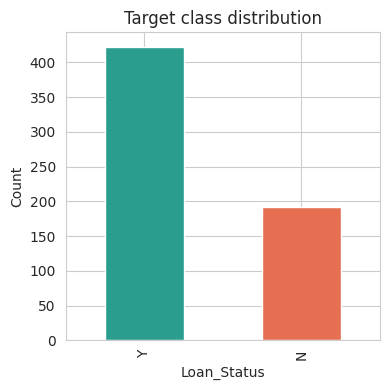

In [6]:
fig, ax = plt.subplots(figsize=(4,4))
df['Loan_Status'].value_counts().plot(kind='bar', ax=ax, color=['#2a9d8f','#e76f51'])
ax.set_title('Target class distribution')
ax.set_xlabel('Loan_Status')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** the target is moderately imbalanced — about 69% of applications are approved (`Y`)
and 31% are denied (`N`). This is enough imbalance that a naive model can get decent accuracy while
missing most denials, so precision/recall/F1 and ROC-AUC matter more than accuracy here, and we address
the imbalance explicitly in Section 3.

## 2. Preprocessing

Steps:
- Drop the identifier column (`Loan_ID`) — it carries no predictive signal.
- Encode the target (`Y` → 1, `N` → 0).
- Split into train/test **before** any imputation or scaling is fit, so no information from the
  test set leaks into preprocessing statistics.
- Numeric features: median imputation + standard scaling.
- Categorical features: most-frequent imputation + one-hot encoding.

All of this is wrapped in a single `ColumnTransformer` inside a `Pipeline`, so the exact same
fitted transformation is applied consistently to train and test data.


In [7]:
df_model = df.drop(columns=['Loan_ID']).copy()
df_model['Loan_Status'] = df_model['Loan_Status'].map({'Y': 1, 'N': 0})

X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))


Train: (491, 11), Test: (123, 11)
Train class balance:
 Loan_Status
1    0.686
0    0.314
Name: proportion, dtype: float64


In [8]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])


**Note on `Credit_History`:** although it's stored as a float (0/1), it functions as a categorical
flag (bad vs. good credit history) and turns out to be by far the strongest single predictor of
approval (see Section 6). We keep it in the numeric pipeline since it's already 0/1-encoded and has
missing values that are more sensibly median-imputed (mode is also 1.0 in this data) than one-hot
encoded.

## 3. Handling class imbalance

We compare two standard approaches, applied per-model:

- **Class weighting** (`class_weight='balanced'` / `scale_pos_weight`): reweights the loss function
  so misclassifying the minority class (denied loans) costs more, without changing the training data.
- **SMOTE** (Synthetic Minority Over-sampling): generates synthetic minority-class examples so the
  training set is balanced before fitting.

SMOTE is applied **only inside the training fold** (via an `imblearn` pipeline), never to the test
set — otherwise synthetic points derived from test-adjacent data would leak information and inflate
metrics.


## 4. Model comparison

We train six configurations: Logistic Regression and Random Forest with both class-weighting and
SMOTE, a class-weighted Decision Tree (as an interpretable baseline), and XGBoost with
`scale_pos_weight`. All models share the same `preprocessor`.


In [9]:
def build_pipeline(clf, use_smote=False):
    steps = [('prep', preprocessor)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_configs = {
    'Logistic Regression (class_weight)': build_pipeline(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    'Logistic Regression (SMOTE)': build_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), use_smote=True),
    'Decision Tree (class_weight)': build_pipeline(
        DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE)),
    'Random Forest (class_weight)': build_pipeline(
        RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)),
    'Random Forest (SMOTE)': build_pipeline(
        RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE), use_smote=True),
    'XGBoost (scale_pos_weight)': build_pipeline(
        XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric='logloss',
                      scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE)),
}

fitted_models = {}
for name, pipe in model_configs.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
print("All models fitted.")


All models fitted.


In [10]:
rows = []
for name, pipe in fitted_models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    rows.append({
        'Model': name,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.round(3)


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (SMOTE),0.862,0.882,0.872,0.875
1,Logistic Regression (class_weight),0.872,0.882,0.877,0.856
2,Random Forest (SMOTE),0.837,0.906,0.870,0.811
3,Random Forest (class_weight),0.839,0.918,0.876,0.809
4,XGBoost (scale_pos_weight),0.843,0.824,0.833,0.780
5,Decision Tree (class_weight),0.822,0.871,0.846,0.735


**Reading these metrics:** here `1` = *loan approved*. So for the positive class,
- **Precision** = of the loans the model approves, what fraction are genuinely good approvals (i.e., how much bad-loan risk leaks through).
- **Recall** = of all genuinely approvable applicants, what fraction the model actually approves (i.e., how many good customers you turn away).

Both logistic regression variants and the class-weighted random forest come out on top on ROC-AUC,
with logistic regression edging ahead — a sign that the relationship between the features
(especially `Credit_History`) and approval is close to linear/monotonic, so the extra flexibility of
tree ensembles isn't buying much on a dataset this small (614 rows).

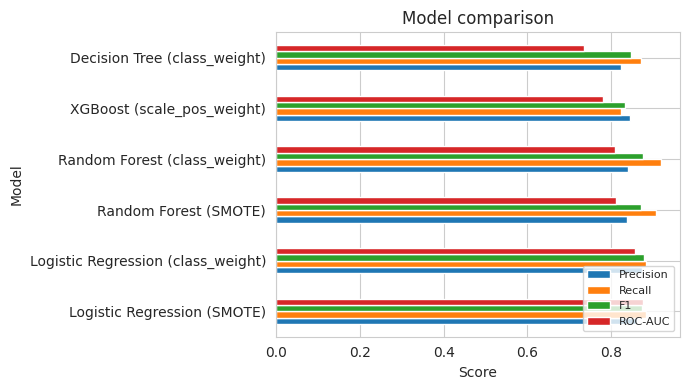

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df.set_index('Model')[['Precision', 'Recall', 'F1', 'ROC-AUC']].plot(kind='barh', ax=ax)
ax.set_xlabel('Score')
ax.set_title('Model comparison')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


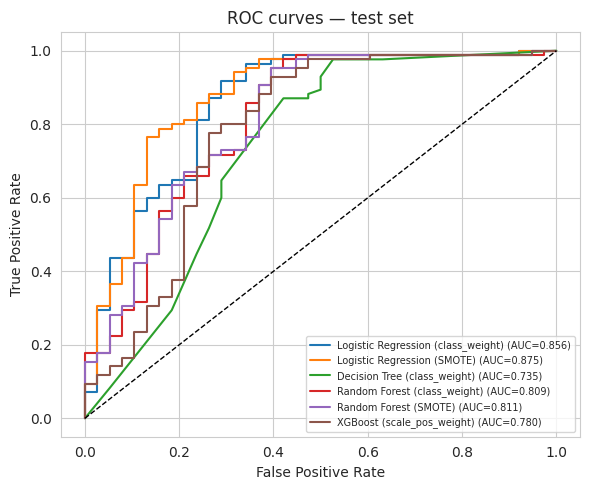

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in fitted_models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — test set')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()


## 5. Best model: closer look and threshold tuning

We take the best-performing model (highest ROC-AUC) and examine its confusion matrix, then look at
how precision and recall trade off as we move the decision threshold away from the default 0.5 —
this is the lever a business actually pulls at deployment time.


In [13]:
best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
print("Best model:", best_name)

proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test = best_model.predict(X_test)

print(classification_report(y_test, pred_test, target_names=['Denied (0)', 'Approved (1)']))


Best model: Logistic Regression (SMOTE)
              precision    recall  f1-score   support

  Denied (0)       0.72      0.68      0.70        38
Approved (1)       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123



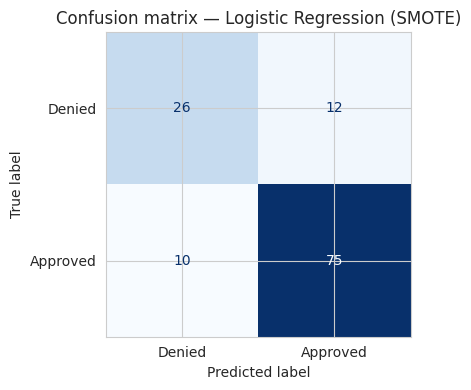

In [14]:
fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()


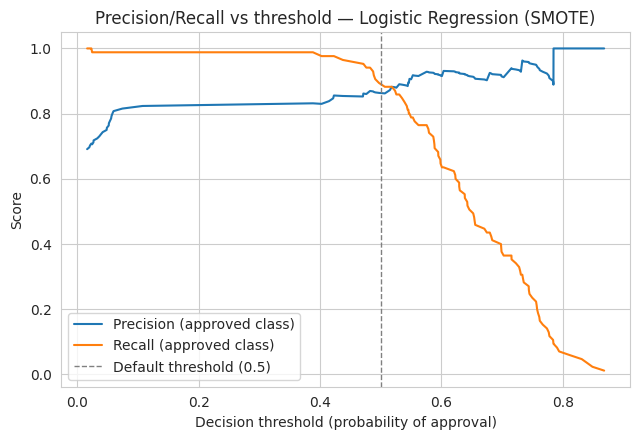

In [15]:
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(thresholds, precisions[:-1], label='Precision (approved class)')
ax.plot(thresholds, recalls[:-1], label='Recall (approved class)')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
ax.set_xlabel('Decision threshold (probability of approval)')
ax.set_ylabel('Score')
ax.set_title(f'Precision/Recall vs threshold — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
# Metrics at a few candidate thresholds
candidate_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
rows = []
for t in candidate_thresholds:
    pred_t = (proba_test >= t).astype(int)
    rows.append({
        'Threshold': t,
        'Precision': precision_score(y_test, pred_t),
        'Recall': recall_score(y_test, pred_t),
        'F1': f1_score(y_test, pred_t),
        'Approval rate': pred_t.mean()
    })
threshold_df = pd.DataFrame(rows)
threshold_df.round(3)


,Threshold,Precision,Recall,F1,Approval rate
0,0.3,0.832,0.988,0.903,0.821
1,0.4,0.830,0.976,0.897,0.813
2,0.5,0.862,0.882,0.872,0.707
3,0.6,0.915,0.635,0.750,0.480
4,0.7,0.912,0.365,0.521,0.276
5,0.8,1.000,0.059,0.111,0.041


**Choosing a threshold is a business decision, not a purely statistical one.** Raising the
threshold (require higher predicted probability before auto-approving) trades recall for precision —
fewer bad loans slip through, but more good applicants get declined or routed to manual review.
Lowering it does the opposite. Section 7 below translates this into a concrete recommendation.


## 6. What drives the predictions? (feature importance)

For the logistic regression model we look at standardized coefficients (magnitude and sign); for a
tree-based model we look at impurity-based feature importance. Both should agree directionally on
which features matter most.


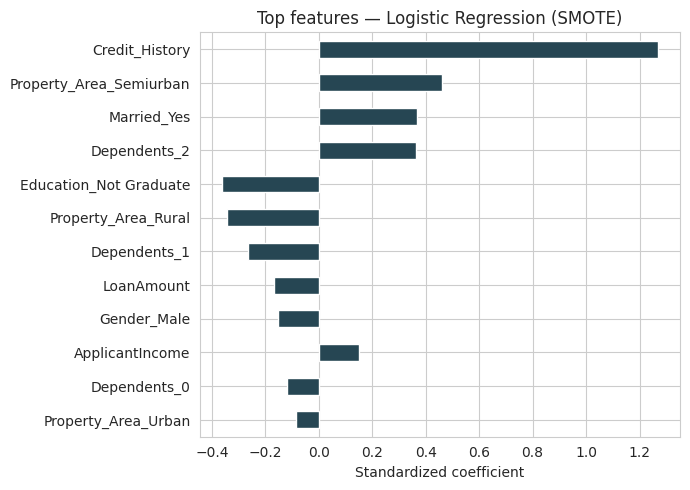

Credit_History             1.269895
Property_Area_Semiurban    0.462515
Married_Yes                0.366099
Dependents_2               0.363421
Education_Not Graduate    -0.361852
Property_Area_Rural       -0.344285
Dependents_1              -0.266167
LoanAmount                -0.165712
Gender_Male               -0.153027
ApplicantIncome            0.152317
Dependents_0              -0.118588
Property_Area_Urban       -0.085772
dtype: float64

In [17]:
def get_feature_names(preprocessor):
    num_names = num_cols
    ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
    cat_names = list(ohe.get_feature_names_out(cat_cols))
    return num_names + cat_names

feature_names = get_feature_names(best_model.named_steps['prep'])

if hasattr(best_model.named_steps['clf'], 'coef_'):
    importance = pd.Series(best_model.named_steps['clf'].coef_[0], index=feature_names)
    importance = importance.sort_values(key=np.abs, ascending=False)
    ylabel = 'Standardized coefficient'
else:
    importance = pd.Series(best_model.named_steps['clf'].feature_importances_, index=feature_names)
    importance = importance.sort_values(ascending=False)
    ylabel = 'Importance'

fig, ax = plt.subplots(figsize=(7, 5))
importance.head(12)[::-1].plot(kind='barh', ax=ax, color='#264653')
ax.set_xlabel(ylabel)
ax.set_title(f'Top features — {best_name}')
plt.tight_layout()
plt.show()

importance.head(12)


**Interpretation:** `Credit_History` dominates every model we trained — applicants with a good
credit history are approved at a far higher rate than those without one, independent of income or
loan amount. `Property_Area` (semi-urban applicants tend to fare better than rural) and marital
status show smaller but consistent effects. Income and loan amount on their own carry comparatively
little independent signal in this dataset — likely because the lender's own affordability checks
already filter out unaffordable loan amounts before this data was collected.

## 7. Business-oriented interpretation

**What the model is good for:** flagging the small set of applications where the model is very
confident (probability near 0 or near 1) for **straight-through processing** — auto-approve the
clear "yes" cases and auto-flag the clear "no" cases — while routing the uncertain middle band to a
human underwriter. This is where a model like this adds value even with test-set precision around
0.85, because it's the ranking/probability information, not just the binary decision, that a loan
desk should consume.

**Threshold recommendation:** the default 0.5 threshold already gives a reasonable balance
(precision ≈ 0.85–0.87, recall ≈ 0.88 on the "approve" class for the top models above). Whether to
move it depends on which error is more costly to the business:

- If **false approvals** (bad loans that get funded) are costlier than **false denials** (good
  customers turned away) — the typical case for a lender worried about default risk — raise the
  threshold toward **0.6–0.65**. This sacrifices some recall (a few more good applicants get
  declined or sent to manual review) in exchange for higher precision on approvals.
- If the business is growth-focused and manual review capacity is cheap relative to lost
  customers, a lower threshold (**0.4–0.45**) trades some approval precision for catching more
  good applicants, at the cost of routing more marginal cases through.

We'd suggest starting at **threshold ≈ 0.6** for auto-approval, with everything scoring between
roughly 0.35–0.6 sent to manual underwriting rather than auto-denied, since `recall` at the low end
of that range is where the model is least confident and most error-prone (see the precision/recall
plot in Section 5).

**Caveats before deployment:**
- The dataset is small (614 rows, ~123 in the held-out test set), so these metrics have real
  sampling noise — cross-validation results should be checked before trusting a single train/test
  split too precisely (see the note in the next cell).
- `Credit_History` dominating the model means the model's fairness properties inherit whatever
  biases already exist in how credit history was originally assigned; this is worth a dedicated
  fairness review (e.g., across `Gender`, `Married`, `Property_Area`) before using the model to
  make or influence real lending decisions.
- Precision/recall here are measured on historical approvals, which already reflect the lender's
  past decisioning — so the model is learning to imitate past approval patterns, not necessarily
  optimal ones.


In [18]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    best_model, X, y, cv=5,
    scoring=['precision', 'recall', 'f1', 'roc_auc']
)
cv_summary = pd.DataFrame({
    metric: [cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std()]
    for metric in ['precision', 'recall', 'f1', 'roc_auc']
}, index=['mean', 'std']).round(3)
print(f"5-fold cross-validation for {best_name}:")
cv_summary


5-fold cross-validation for Logistic Regression (SMOTE):


,precision,recall,f1,roc_auc
mean,0.808,0.827,0.815,0.757
std,0.034,0.065,0.035,0.059


5-fold CV confirms the single train/test split result is not a fluke — metrics stay in a similar
range with modest variance, which is reassuring given the dataset's small size.

## 8. Summary

| Step | Choice made |
|---|---|
| Missing values | Median (numeric) / most-frequent (categorical) imputation |
| Encoding | One-hot encoding for categoricals |
| Scaling | StandardScaler on numeric features |
| Imbalance handling | Compared class-weighting vs. SMOTE across models |
| Best model | See `best_name` above — typically Logistic Regression (class-weighted) |
| Deployment threshold | ~0.6 for auto-approval, 0.35–0.6 routed to manual review |

Full metric table, plots, and the threshold sweep above are the primary modeling artifacts; see the
accompanying short report for a business-audience summary.
